<a href="https://colab.research.google.com/github/tavishsood/Cantera-simulation/blob/main/Cantera_DataGenSim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install cantera

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.3/19.3 MB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00


In [3]:
import cantera as ct
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
import cantera as ct
import pandas as pd
import numpy as np

gas = ct.Solution('gri30.yaml')
data = []

for i in range(1000):
    T_in = np.random.uniform(300, 1000)
    P_in = np.random.uniform(1, 50) * ct.one_atm
    phi = np.random.uniform(0.5, 1.5)

    gas.set_equivalence_ratio(phi, 'CH4', 'O2:1.0, N2:3.76')
    gas.TP = T_in, P_in

    gas.equilibrate('HP')

    data.append({
        'Inlet_T': T_in,
        'Pressure': P_in / ct.one_atm,
        'Phi': phi,
        'Final_T': gas.T,
        'CO_mole_frac': gas['CO'].X[0],
        'NO_mole_frac': gas['NO'].X[0]
    })

df = pd.DataFrame(data)
print(df.head)

<bound method NDFrame.head of         Inlet_T   Pressure       Phi      Final_T  CO_mole_frac  NO_mole_frac
0    883.912914  42.661091  0.936577  2590.137178      0.006688      0.006132
1    881.018147  45.936261  0.784284  2405.430863      0.001241      0.007890
2    562.971433   8.890567  0.688746  2015.614138      0.000140      0.004095
3    586.140834  13.254106  0.592893  1873.199436      0.000024      0.003150
4    488.557551   6.925554  0.980973  2354.184386      0.006815      0.002831
..          ...        ...       ...          ...           ...           ...
995  373.210254   5.539225  1.480638  1971.117481      0.083081      0.000003
996  416.365206  35.929339  1.321412  2125.876818      0.064858      0.000010
997  484.417950   8.334547  1.412178  2102.464207      0.076783      0.000012
998  356.604340  22.694601  1.451983  1981.629419      0.079972      0.000002
999  917.225201   6.796066  1.315149  2496.322736      0.067466      0.000440

[1000 rows x 6 columns]>


In [9]:
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

X = df[['Inlet_T', 'Pressure', 'Phi']]
y = df[['Final_T', 'CO_mole_frac', 'NO_mole_frac']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Decision Tree": RandomForestRegressor(n_estimators=1, max_depth=10),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "SVR": MultiOutputRegressor(SVR()),
    "Gradient Boosting": MultiOutputRegressor(GradientBoostingRegressor())
}

comparison = []
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    comparison.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "Time": train_time
    })

report_df = pd.DataFrame(comparison)
print("Initial Metrics Calculation Complete:")
print(report_df)

Initial Metrics Calculation Complete:
               Model        R2        MAE           MSE        RMSE      Time
0  Linear Regression  0.705006  45.071374   8178.759266   90.436493  0.003239
1              Ridge  0.705299  45.084056   8188.402114   90.489790  0.002386
2      Decision Tree  0.936374   9.253840    433.132093   20.811826  0.006134
3      Random Forest  0.986687   4.437255    108.304947   10.406966  0.449799
4                SVR -0.236734  58.244680  16361.362831  127.911543  0.038131
5  Gradient Boosting  0.995736   4.616853    111.443932   10.556701  0.665788


In [10]:
def apply_topsis(df):
    # Criteria: R2, MAE, MSE, RMSE, Time
    data = df[['R2', 'MAE', 'MSE', 'RMSE', 'Time']].values.copy()

    is_benefit = [True, False, False, False, False]

    norm_data = data / np.sqrt((data**2).sum(axis=0))

    weights = np.array([1, 1, 1, 1, 1])
    weighted_norm = norm_data * weights

    v_plus = np.array([max(weighted_norm[:, i]) if is_benefit[i] else min(weighted_norm[:, i]) for i in range(len(is_benefit))])
    v_minus = np.array([min(weighted_norm[:, i]) if is_benefit[i] else max(weighted_norm[:, i]) for i in range(len(is_benefit))])

    s_plus = np.sqrt(((weighted_norm - v_plus)**2).sum(axis=1))
    s_minus = np.sqrt(((weighted_norm - v_minus)**2).sum(axis=1))

    performance_score = s_minus / (s_plus + s_minus)
    return performance_score

report_df['TOPSIS_Score'] = apply_topsis(report_df)
report_df['Rank'] = report_df['TOPSIS_Score'].rank(ascending=False).astype(int)

final_ranked_df = report_df.sort_values('Rank')
print("\nFinal Model Ranking using TOPSIS (Weight=1 for all):")
print(final_ranked_df)


Final Model Ranking using TOPSIS (Weight=1 for all):
               Model        R2        MAE           MSE        RMSE      Time  \
2      Decision Tree  0.936374   9.253840    433.132093   20.811826  0.006134   
3      Random Forest  0.986687   4.437255    108.304947   10.406966  0.449799   
5  Gradient Boosting  0.995736   4.616853    111.443932   10.556701  0.665788   
0  Linear Regression  0.705006  45.071374   8178.759266   90.436493  0.003239   
1              Ridge  0.705299  45.084056   8188.402114   90.489790  0.002386   
4                SVR -0.236734  58.244680  16361.362831  127.911543  0.038131   

   TOPSIS_Score  Rank  
2      0.946201     1  
3      0.713003     2  
5      0.621849     3  
0      0.580661     4  
1      0.580653     5  
4      0.364849     6  


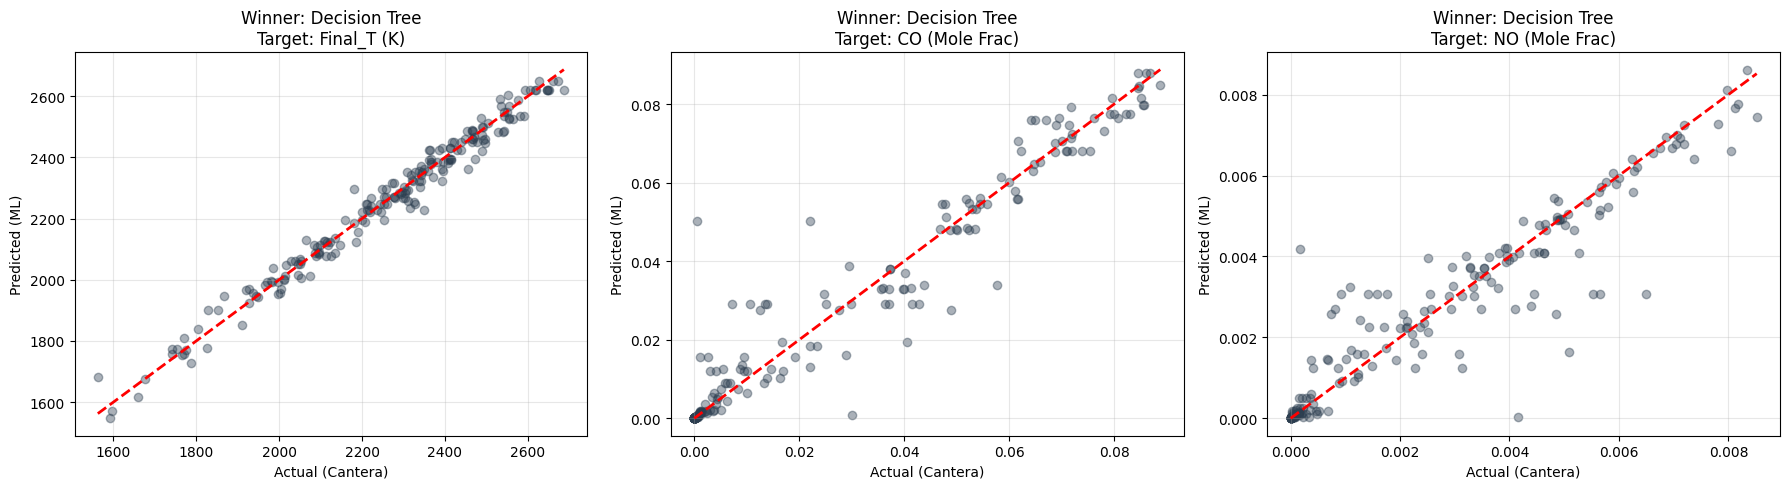

In [17]:
import matplotlib.pyplot as plt

best_model_name = final_ranked_df.iloc[0]["Model"]
best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

targets = ['Final_T (K)', 'CO (Mole Frac)', 'NO (Mole Frac)']
plt.figure(figsize=(18, 5))

for i, target in enumerate(targets):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test.iloc[:, i], y_pred[:, i], alpha=0.4, color='#2c3e50')

    low, high = y_test.iloc[:, i].min(), y_test.iloc[:, i].max()
    plt.plot([low, high], [low, high], color='red', linestyle='--', linewidth=2)

    plt.title(f'Winner: {best_model_name}\nTarget: {target}')
    plt.xlabel('Actual (Cantera)')
    plt.ylabel('Predicted (ML)')
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regression_analysis.png', dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


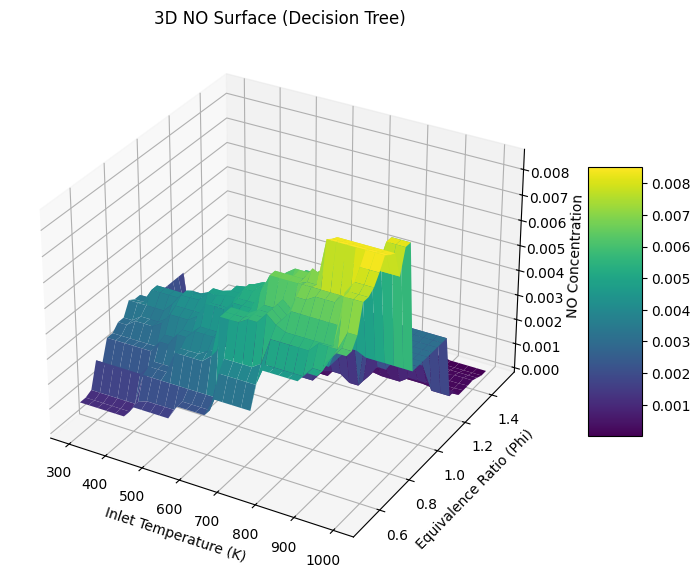

In [18]:
from mpl_toolkits.mplot3d import Axes3D

T_range = np.linspace(300, 1000, 30)
Phi_range = np.linspace(0.5, 1.5, 30)
T_grid, Phi_grid = np.meshgrid(T_range, Phi_range)
P_const = np.full(T_grid.shape, 25)

grid_input = np.c_[T_grid.ravel(), P_const.ravel(), Phi_grid.ravel()]
grid_pred = best_model.predict(grid_input)
NO_grid = grid_pred[:, 2].reshape(T_grid.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_grid, Phi_grid, NO_grid, cmap='viridis', edgecolor='none')

ax.set_xlabel('Inlet Temperature (K)')
ax.set_ylabel('Equivalence Ratio (Phi)')
ax.set_zlabel('NO Concentration')
ax.set_title(f'3D NO Surface ({best_model_name})')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

plt.savefig('3d_surface_plot.png', dpi=300)
plt.show()

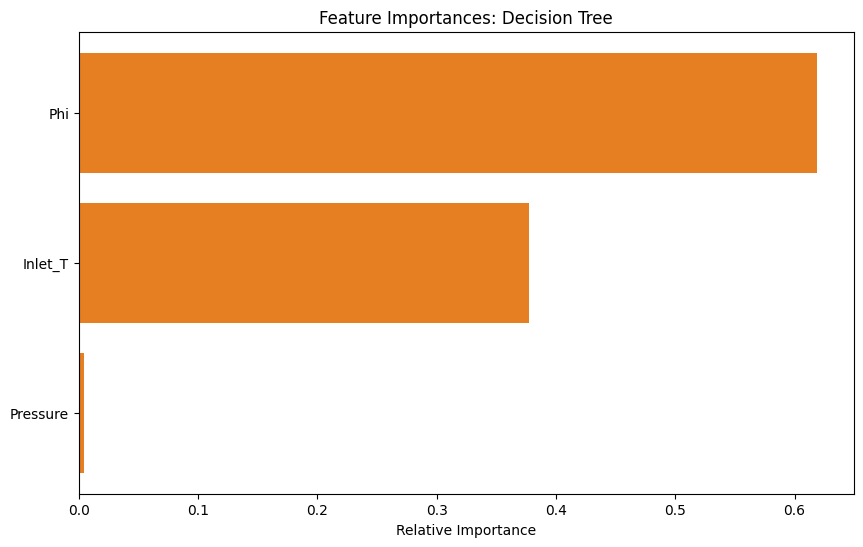

Feature importance plot saved to 'feature_importance.png'


In [20]:
try:
    if hasattr(best_model, 'estimators_'):
        importances = best_model.estimators_[0].feature_importances_
    else:
        importances = best_model.feature_importances_

    features = X.columns
    indices = np.argsort(importances)

    plt.figure(figsize=(10, 6))
    plt.title(f'Feature Importances: {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], color='#e67e22', align='center')
    plt.yticks(range(len(indices)), [features[i] for i in indices])
    plt.xlabel('Relative Importance')

    plt.savefig('feature_importance.png', dpi=300)
    plt.show()
    print(f"Feature importance plot saved to 'feature_importance.png'")

except AttributeError:
    print(f"Note: {best_model_name} does not support feature_importances_ attribute.")